### Import Library

In [1]:
import numpy as np 
import yfinance as yf 
import pandas as pd 
import plotly.graph_objects as go
from plotly.subplots import make_subplots

### Data Loading & Correlation Matrix

In [2]:
tickers = ["AMZN", "MSFT"]
data = yf.download(tickers, start="2020-1-1", end="2026-1-1")["Close"]
returns = data.pct_change().dropna()

print(returns)

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  2 of 2 completed

Ticker          AMZN      MSFT
Date                          
2020-01-03 -0.012139 -0.012452
2020-01-06  0.014886  0.002585
2020-01-07  0.002092 -0.009118
2020-01-08 -0.007809  0.015928
2020-01-09  0.004799  0.012493
...              ...       ...
2025-12-24  0.001034  0.002403
2025-12-26  0.000602 -0.000635
2025-12-29 -0.001935 -0.001251
2025-12-30  0.001982  0.000780
2025-12-31 -0.007354 -0.007918

[1507 rows x 2 columns]


In [19]:
correlation = returns.corr().values
print(f"Correlation Matrix :\n {np.round(correlation, 4)}")

Correlation Matrix :
 [[1.    0.665]
 [0.665 1.   ]]


### Choleky Numpy Method

In [4]:
def choleky_numpy(A):
    return np.linalg.cholesky(A)

### Choleky Manual Method

In [5]:
def cholesky_manual(A):
    n = A.shape[0]
    L = np.zeros((n,n))

    for i in range(n):
        for j in range(i+1):
            s = sum(L[i,k] * L[j,k] for k in range(j))
            if i == j:
                L[i,j] = np.sqrt(A[i,i] - s)
            else:
                L[i,j] = (A[i,j] - s) / L[j,j]
    return L

### Test 

In [23]:
L_numpy = choleky_numpy(correlation)
L_manual = cholesky_manual(correlation)

print(f"L manual :\n {np.round(L_manual, 3)}")
print(f"\nL numpy  :\n {np.round(L_numpy, 3)}")

print(f"\nVerification L @ L.T :\n {np.round(L_manual @ L_manual.T, 3)}")

L manual :
 [[1.    0.   ]
 [0.665 0.747]]

L numpy  :
 [[1.    0.   ]
 [0.665 0.747]]

Verification L @ L.T :
 [[1.    0.665]
 [0.665 1.   ]]


### Monte Carlo with Cholesky 

In [7]:
def monte_carlo_cholesky(returns, n_sample, seed=42):
    # Correlation Matrix + Cholesky
    C = returns.corr().values
    L = np.linalg.cholesky(C)

    # Independent Variable
    n_assets = C.shape[1]
    Z = np.random.standard_normal((n_assets, n_sample))

    # Correlated Variables
    X = L @ Z

    # Dataframe
    simulated = pd.DataFrame(X.T, columns=returns.columns)

    # Rescale 
    for col in simulated.columns:
        simulated[col] = simulated[col] * returns[col].std() + returns[col].mean()

    return simulated

### Test

In [8]:
n_samples = 10000
simulated_returns = monte_carlo_cholesky(returns, n_samples)

print(f"Real Correlation : \n {round(returns.corr(), 4)}")
print()
print(f"Simulated Correlation : \n {round(simulated_returns.corr(), 4)}")

Real Correlation : 
 Ticker   AMZN   MSFT
Ticker              
AMZN    1.000  0.665
MSFT    0.665  1.000

Simulated Correlation : 
 Ticker    AMZN    MSFT
Ticker                
AMZN    1.0000  0.6633
MSFT    0.6633  1.0000


### Plot

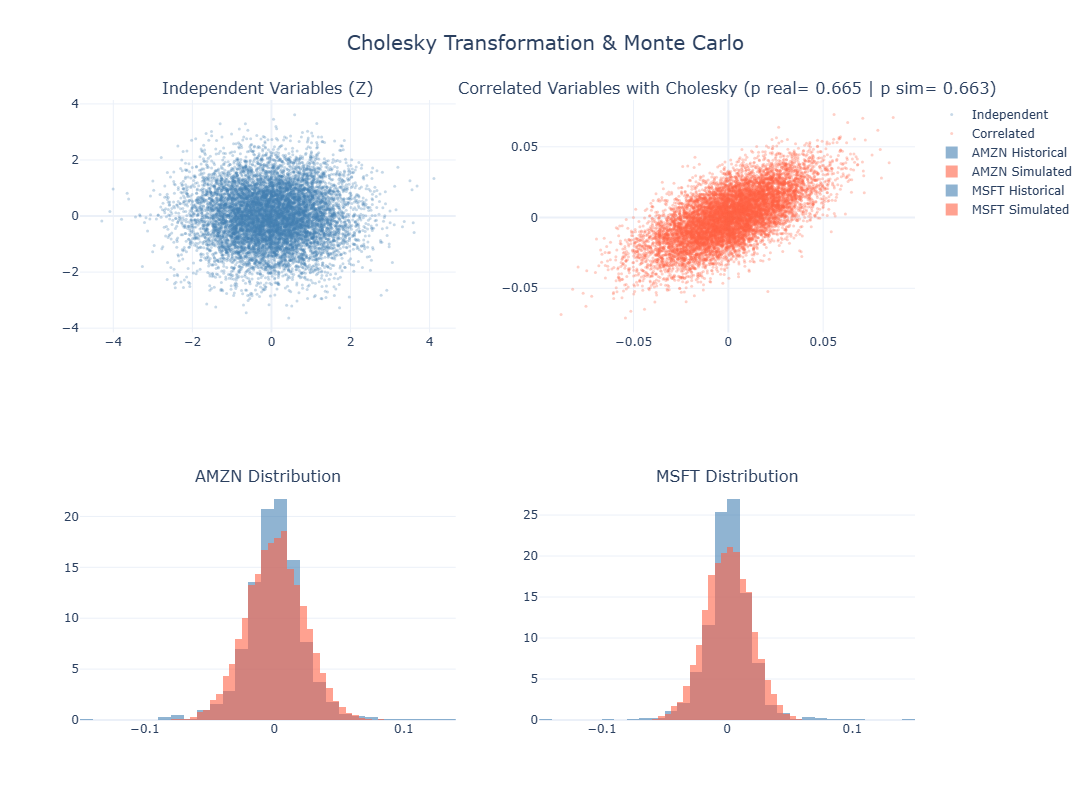

In [12]:
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        "Independent Variables (Z)",
        f"Correlated Variables with Cholesky (p real={returns.corr().iloc[0,1]: .3f} | p sim={simulated_returns.corr().iloc[0,1]: .3f})",
        f"{tickers[0]} Distribution",
        f"{tickers[1]} Distribution"
    )
)

# Scatter Plot Z Independent
n_assets = 2
Z = np.random.standard_normal((n_assets, n_samples))

fig.add_trace(
    go.Scatter(
        x=Z[0], y=Z[1],
        mode="markers",
        marker=dict(size=3, color="steelblue", opacity=0.3),
        name="Independent"
    ),
    row=1, col=1
)

# Scatter Plot X Correlated
fig.add_trace(
    go.Scatter(
        x=simulated_returns.iloc[:, 0],
        y=simulated_returns.iloc[:, 1],
        mode="markers",
        marker=dict(size=3, color="tomato", opacity=0.3),
        name="Correlated"
    ),
    row=1, col=2
)

# Historical Vs Simulated Distribution 
for col_idx, ticker in enumerate(tickers, start=1):
    # Historique
    fig.add_trace(
        go.Histogram(
            x=returns[ticker],
            nbinsx=50,
            histnorm="probability density",
            opacity=0.6,
            name=f"{ticker} Historical",
            marker_color="steelblue"
        ),
        row=2, col=col_idx
    )
    # Simulé
    fig.add_trace(
        go.Histogram(
            x=simulated_returns[ticker],
            nbinsx=50,
            histnorm="probability density",
            opacity=0.6,
            name=f"{ticker} Simulated",
            marker_color="tomato"
        ),
        row=2, col=col_idx
    )


# Layout
fig.update_layout(
    title=dict(
        text="Cholesky Transformation & Monte Carlo",
        font=dict(size=20),
        x=0.5
    ),
    height=800,
    barmode="overlay",
    template="plotly_white",  # ou "plotly_white" selon ta préférence
    showlegend=True
)

fig.show()

fig.write_image("cholesky_monte_carlo.png", scale=3, width=1400, height=800)